In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../Task_1_Data_Cleaning/cleaned_superstore.csv')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


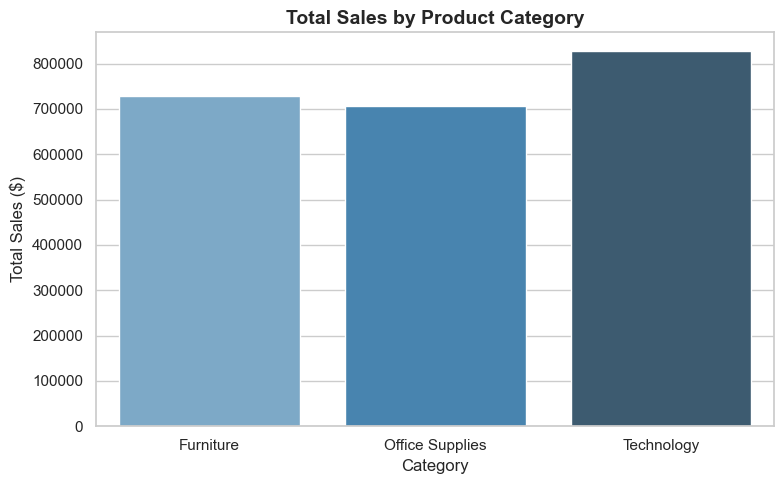

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', hue='Category', palette='Blues_d')
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

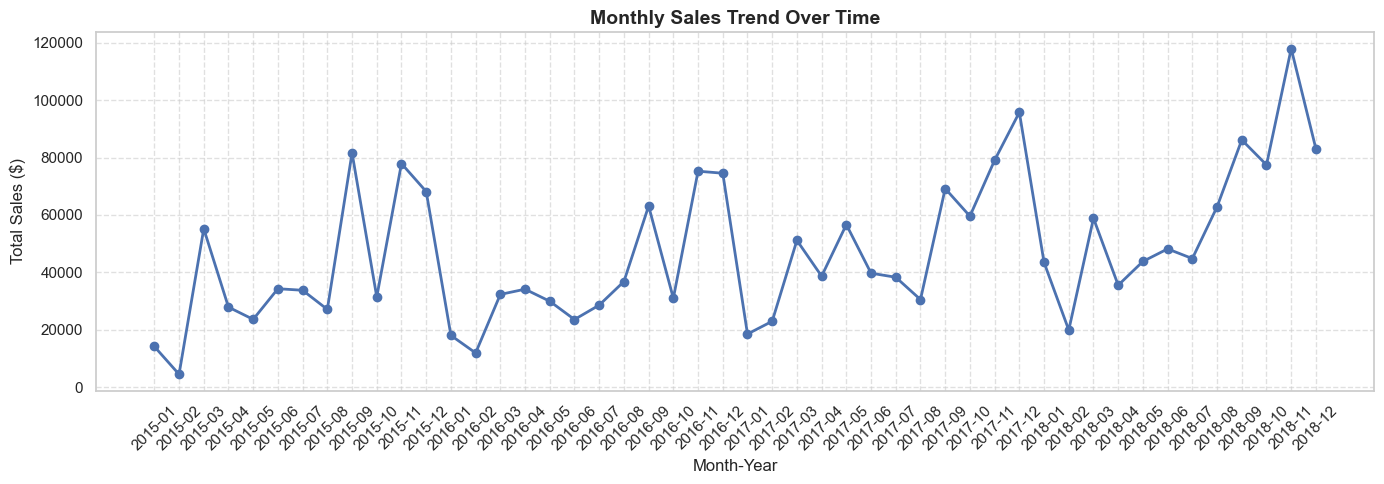

In [ ]:
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Year_Month')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Year_Month'], monthly_sales['Sales'], marker='o', color='b', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

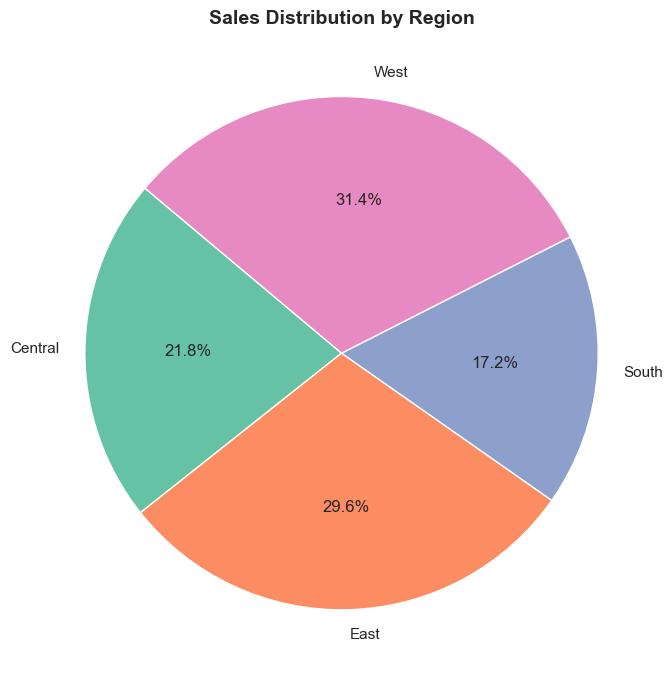

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

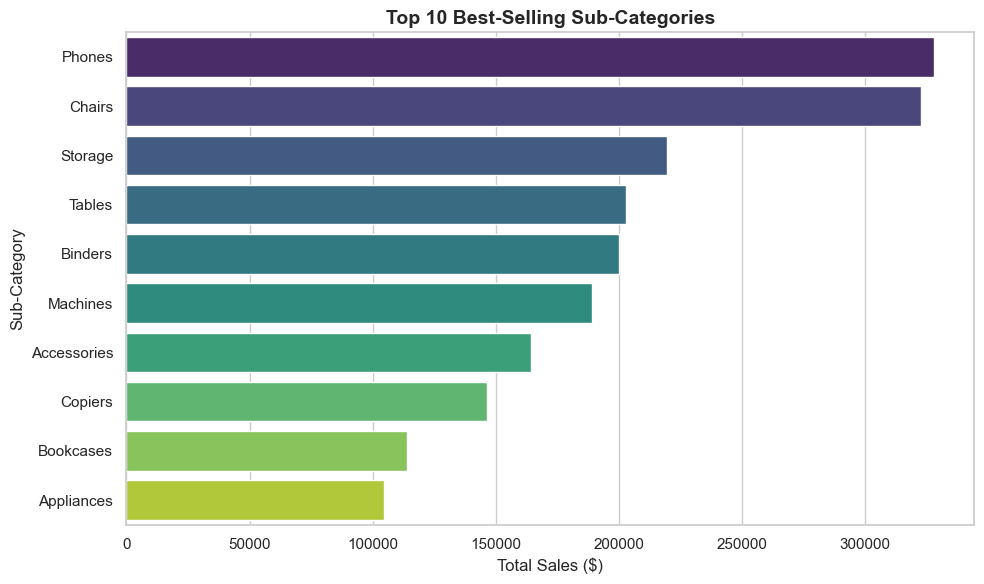

In [ ]:
top_subcats = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_subcats, y='Sub_Category', x='Sales', hue='Sub_Category', palette='viridis')
plt.title('Top 10 Best-Selling Sub-Categories', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()